In [1]:
from src import clustering, graph_utils, plotting
import squidpy as sq
import scanpy as sc
import warnings
warnings.filterwarnings("ignore")
import os
import spatialdata as sd
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from napari_spatialdata import Interactive

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = sc.read_h5ad("C://Users//laure//Desktop//github//adaptive_niche_data//cosmx.h5ad")
adata = adata[adata.obs["section"] == "section_4", :].copy()

In [2]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")
sdata = sd.read_zarr(f"C://Users//laure//Desktop//github//sys_gen//zarr//{dirs[4]}")
adata = sdata.tables["table"]

In [3]:
clustering.fit_gmm(adata, nn_distance=5, k_range=range(1,10)) #calculates distance to 1st nearest neighbor, then fits GMMs and chooses best one based on ICL
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=20) #no reason to wrap this in another function
graph_utils.prune_graph_new(adata, gmm_key="gmm_labels", distance_key="5_nn_distance", prune_by="distance", n_std=3)
clustering.watershed(adata, distances_key="5_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities", niche_key="watershed")

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. Stored in 'pruned_spatial_connectivities'.
assigning colors...


In [ ]:
Interactive(sdata)

In [4]:
def compute_local_density(dist_matrix: csr_matrix):
    """
    Compute local density per node using inverse mean neighbor distance.
    """
    dist_matrix = dist_matrix.tocsr()
    
    densities = np.zeros(dist_matrix.shape[0])

    for i in range(dist_matrix.shape[0]):
        start, end = dist_matrix.indptr[i], dist_matrix.indptr[i+1]
        dists = dist_matrix.data[start:end]

        if len(dists) > 0:
            densities[i] = 1.0 / np.mean(dists)
        else:
            densities[i] = 0

    return densities


def graph_metrics(adj: csr_matrix, densities, region_labels):
    """
    Compute:
    - edge density variance
    - boundary crossing rate
    - mean density difference
    """
    
    adj = adj.tocsr()
    
    rows, cols = adj.nonzero()

    # avoid double counting for symmetric graphs
    mask = rows < cols
    rows = rows[mask]
    cols = cols[mask]

    rho_i = densities[rows]
    rho_j = densities[cols]

    density_diffs = rho_i - rho_j

    edge_density_variance = np.mean(density_diffs ** 2)
    mean_density_difference = np.mean(np.abs(density_diffs))

    region_i = region_labels[rows]
    region_j = region_labels[cols]

    boundary_crossings = np.sum(region_i != region_j)
    boundary_crossing_rate = boundary_crossings / len(rows)

    return {
        "edge_density_variance": edge_density_variance,
        "mean_density_difference": mean_density_difference,
        "boundary_crossing_rate": boundary_crossing_rate,
        "n_edges": len(rows)
    }


def compare_graphs(
    adata,
    knn_adj_key="connectivities_knn",
    adaptive_adj_key="connectivities_adaptive",
    knn_dist_key="distances_knn",
    adaptive_dist_key="distances_adaptive",
    region_key="density_region"
):

    knn_adj = adata.obsp[knn_adj_key]
    adaptive_adj = adata.obsp[adaptive_adj_key]

    knn_dist = adata.obsp[knn_dist_key]
    adaptive_dist = adata.obsp[adaptive_dist_key]

    regions = adata.obs[region_key].values

    # compute densities from each graph's distances
    rho_knn = compute_local_density(knn_dist)
    rho_adaptive = compute_local_density(adaptive_dist)

    knn_metrics = graph_metrics(knn_adj, rho_knn, regions)
    adaptive_metrics = graph_metrics(adaptive_adj, rho_adaptive, regions)

    results = pd.DataFrame(
        [knn_metrics, adaptive_metrics],
        index=["knn_graph", "adaptive_graph"]
    )

    return results

In [7]:
adata

AnnData object with n_obs × n_vars = 162033 × 248
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', '1_nn_distance', 'gmm_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances', 'pruned_spatial_connectivities', 'pruned_spatial_distances'

1-NN dist & 20 n_neighs

In [10]:
compare_graphs(adata, "spatial_connectivities", "pruned_spatial_connectivities", "spatial_distances", "pruned_spatial_distances", "gmm_labels")

,edge_density_variance,mean_density_difference,boundary_crossing_rate,n_edges
knn_graph,0.000027,0.003556,0.651447,1619936
adaptive_graph,0.000709,0.016794,0.430768,162967


In [5]:
compare_graphs(adata, "spatial_connectivities", "pruned_spatial_connectivities", "spatial_distances", "pruned_spatial_distances", "gmm_labels")

,edge_density_variance,mean_density_difference,boundary_crossing_rate,n_edges
knn_graph,0.000027,0.003556,0.651447,1619936
adaptive_graph,0.000077,0.005050,0.072933,100064


1-NN dist & 6 n_neighs

In [16]:
compare_graphs(adata, "spatial_connectivities", "pruned_spatial_connectivities", "spatial_distances", "pruned_spatial_distances", "gmm_labels")

,edge_density_variance,mean_density_difference,boundary_crossing_rate,n_edges
knn_graph,0.000112,0.007748,0.577550,485899
adaptive_graph,0.000698,0.016641,0.428365,162177


In [7]:
compare_graphs(adata, "spatial_connectivities", "pruned_spatial_connectivities", "spatial_distances", "pruned_spatial_distances", "gmm_labels")

,edge_density_variance,mean_density_difference,boundary_crossing_rate,n_edges
knn_graph,0.000112,0.007748,0.577550,485899
adaptive_graph,0.000077,0.005050,0.073024,99940


In [4]:
sc.pp.neighbors(adata, n_neighbors=20)

In [5]:
sq.gr.calculate_niche(adata, flavor="spatialleiden", resolutions=[1.0], spatial_connectivities_key="spatial_connectivities", latent_connectivities_key="distances")
sq.gr.calculate_niche(adata, flavor="utag", resolutions=[1.0], n_neighbors=20, spatial_connectivities_key="spatial_connectivities", latent_connectivities_key="distances")
#sq.gr.calculate_niche(adata, flavor="cellcharter", distance=5, aggregation="mean", n_components=5 ,spatial_connectivities_key="spatial_connectivities", latent_connectivities_key="distances")

WARNING  Parameters distance are not used for flavor 'utag'.                                                       


In [6]:
adata.obs = adata.obs.rename(columns={'spatialleiden_res=1.0': 'spatialleiden', 'utag_niche_res=1.0': 'utag_niche'})

In [7]:
sq.gr.calculate_niche(adata, flavor="spatialleiden", resolutions=[1.0], spatial_connectivities_key="pruned_spatial_connectivities", latent_connectivities_key="distances")
sq.gr.calculate_niche(adata, flavor="utag", resolutions=[1.0], n_neighbors=20, spatial_connectivities_key="pruned_spatial_connectivities", latent_connectivities_key="distances")
#sq.gr.calculate_niche(adata, flavor="cellcharter", distance=5, aggregation="mean", n_components=5 ,spatial_connectivities_key="pruned_spatial_connectivities", latent_connectivities_key="distances")


WARNING  Parameters distance are not used for flavor 'utag'.                                                       


In [ ]:
adata.obs = adata.obs.rename(columns={'spatialleiden_res=1.0': 'spatialleiden_pruned_new', 'utag_niche_res=1.0': 'utag_niche_pruned_new'})

In [ ]:
plotting.assign_colors(adata, "utag_niche_pruned_new")

In [11]:
plotting.assign_colors(adata, "watershed")

In [ ]:
Interactive(sdata)

2026-03-09 21:13:26.541 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2026-03-09 21:13:31.289 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-03-09 21:13:31.707 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


In [16]:
adata.obs["watershed"].nunique()

13427

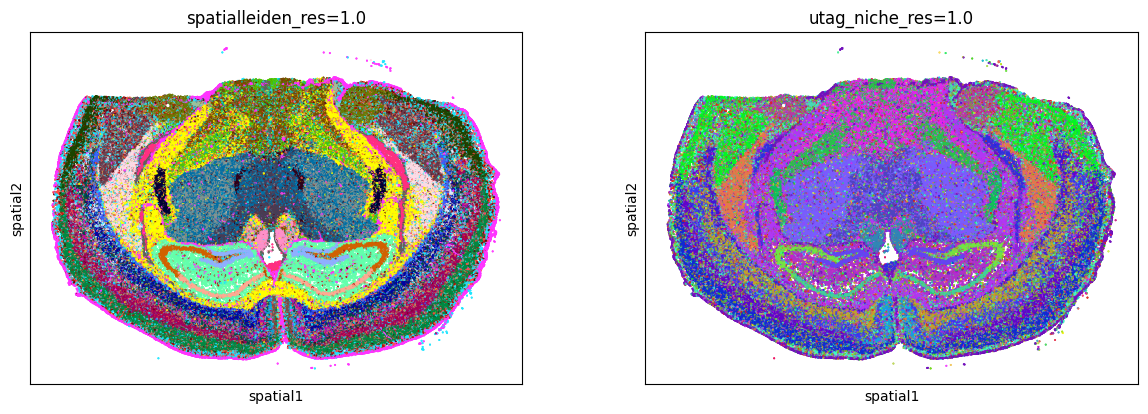

In [11]:
sq.pl.spatial_scatter(adata, color=["spatialleiden_res=1.0", "utag_niche_res=1.0"], shape=None, legend_loc=None)


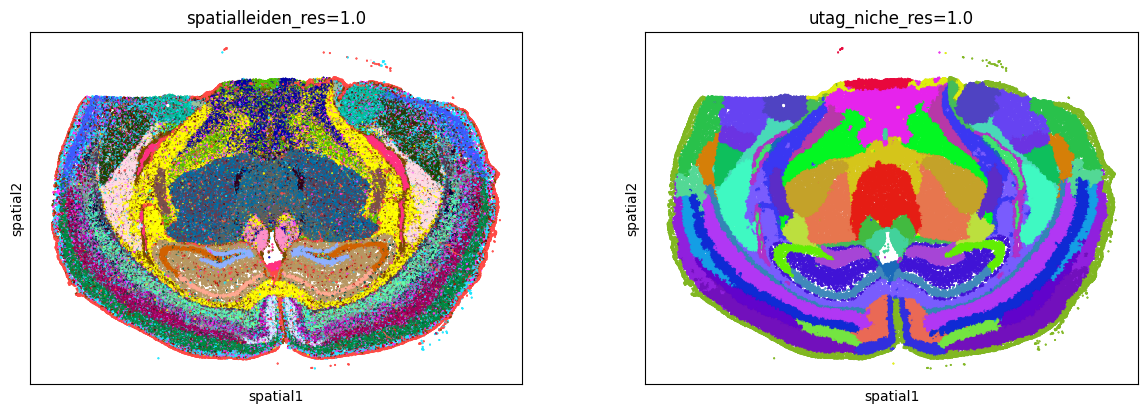

In [15]:
sq.pl.spatial_scatter(adata, color=["spatialleiden_res=1.0", "utag_niche_res=1.0"], shape=None, legend_loc=None)


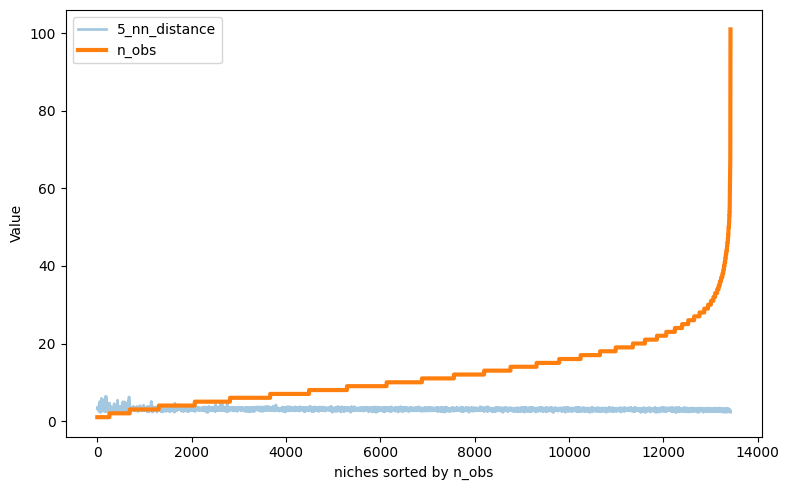

In [17]:
plotting.plot_niche_stats(adata, col_keys=["5_nn_distance","n_obs"], category_key="watershed", sort_by="n_obs", normalize=False)

In [17]:
Interactive(sdata)

2026-03-09 00:10:31.771 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.
